In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

### Default Technology Database

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [3]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

- all costs are annualised

In [4]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

### Weather Data

In [90]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

In [9]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
print(PV_data.head())

                     DK01  DK02  DK03  DK04  DK05
time                                             
1980-01-01 00:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 01:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 02:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 03:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 04:00:00   0.0   0.0   0.0   0.0   0.0


In [54]:
CF_solar = PV_data["DK01"]

<Axes: xlabel='time'>

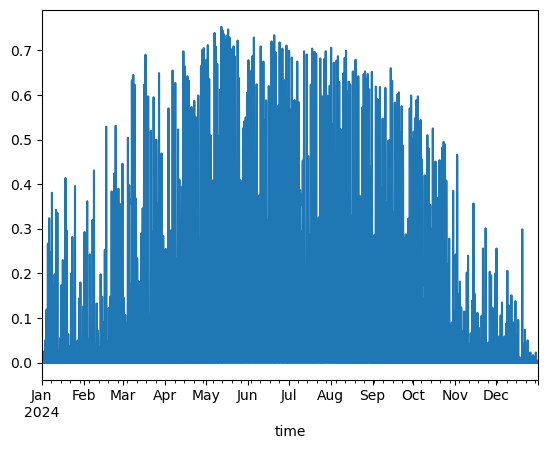

In [66]:
CF_solar["2024"].plot()

In [16]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()

print(OnshoreWind_Data.head())

                     NATIONAL      DK01      DK02      DK03      DK04  \
time                                                                    
1980-01-01 00:00:00  0.100020  0.169258  0.154797  0.058525  0.082945   
1980-01-01 01:00:00  0.095627  0.157692  0.155743  0.059855  0.076598   
1980-01-01 02:00:00  0.090815  0.145822  0.156026  0.060255  0.070185   
1980-01-01 03:00:00  0.082520  0.134984  0.153629  0.058150  0.058770   
1980-01-01 04:00:00  0.071892  0.122622  0.150896  0.054550  0.042691   

                         DK05  
time                           
1980-01-01 00:00:00  0.120442  
1980-01-01 01:00:00  0.112279  
1980-01-01 02:00:00  0.103703  
1980-01-01 03:00:00  0.092318  
1980-01-01 04:00:00  0.080078  


In [55]:
CF_wind = OnshoreWind_Data["DK01"]

<Axes: xlabel='time'>

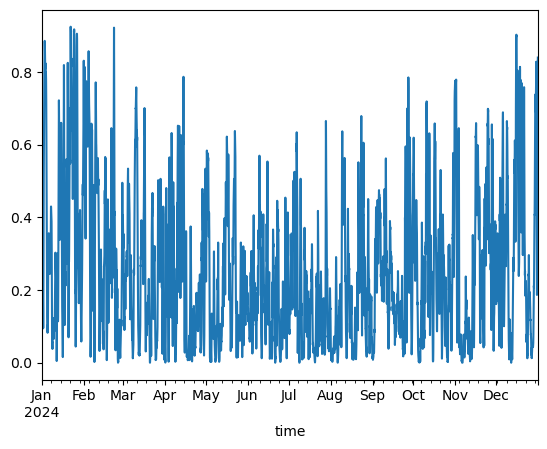

In [63]:
CF_wind["2024"].plot()

### SpotPrice Data

In [18]:
elspotprices = pd.read_excel("Elspotprices2021_2025.xlsx", index_col=0, parse_dates=True) # EUR/MWh
elspotprices.head()

,HourDK,PriceArea,SpotPriceDKK,SpotPriceEUR
HourUTC,,,,
2021-12-28 23:00:00,2021-12-29 00:00:00,DK1,833.280029,112.059998
2021-12-29 00:00:00,2021-12-29 01:00:00,DK1,693.559998,93.269997
2021-12-29 01:00:00,2021-12-29 02:00:00,DK1,701.739990,94.370003
2021-12-29 02:00:00,2021-12-29 03:00:00,DK1,675.340027,90.820000
2021-12-29 03:00:00,2021-12-29 04:00:00,DK1,699.059998,94.010002


In [23]:
elspotprices["SpotPriceEUR"]

HourUTC
2021-12-28 23:00:00    112.059998
2021-12-29 00:00:00     93.269997
2021-12-29 01:00:00     94.370003
2021-12-29 02:00:00     90.820000
2021-12-29 03:00:00     94.010002
                          ...    
2025-09-30 17:00:00    357.769989
2025-09-30 18:00:00    147.279999
2025-09-30 19:00:00    116.040001
2025-09-30 20:00:00    101.629997
2025-09-30 21:00:00     92.540001
Name: SpotPriceEUR, Length: 32927, dtype: float64

In [17]:
DKK_Euro = 7.468  #https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-dkk.en.html

el_transmission_tariff = 4.3 / 100 * 1000 / DKK_Euro   # from energinet inputs in Ore/kWh DKK/MWh, bef 7.5
el_system_tariff = 7.2 / 100 * 1000 / DKK_Euro   # bef 5.1
el_afgift =  0.8 / 100 * 1000 / DKK_Euro         # bef 76.1 https://skm.dk/tal-og-metode/satser/satser-og-beloebsgraenser-i-lovgivningen/elafgiftsloven  https://elberegner.dk/guides/elafgift/
 
# DSO Tariff -  for 60/10kV transformer (A_low customer) #Staring from January 2026 https://n1.dk/elnetkunder/kommende-priser
el_net_tariff_low = 1.54  / 100 * 1000 / DKK_Euro   # Ore/kWh to eur/MWh
el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro
el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro

VAT = 0.25 # 25 % VAT (Value Added Tax)

- function to generate import/export price of electricity

In [19]:
from types import SimpleNamespace

p = SimpleNamespace(

    # Model year (for defining summer/winter periods)
    En_price_year = 2017,

    # Full analysis period
    start_date = "2017-01-01",
    end_date   = "2018-01-01",

    # Fixed tariffs (constant every hour)
    el_transmission_tariff =  4.3 / 100 * 1000 / DKK_Euro , # 
    el_system_tariff       =  7.2 / 100 * 1000 / DKK_Euro,
    el_afgift              = 0.8 / 100 * 1000 / DKK_Euro   ,

    # Selling tariff (when exporting to grid)
    el_tariff_sell = (0.5 + 0.53)/100 * 1000 / DKK_Euro,  # Average of 0.5 and 0.53 DKK/kWh

    # Variable tariff levels
    el_net_tariff_low  = 1.54  / 100 * 1000 / DKK_Euro,
    el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro,
    el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro
)

# 2. PRICE CALCULATION FUNCTION
# ============================================================
def build_electricity_grid_price_w_tariff(Elspotprices):
    """
    Inputs:
        Elspotprices : pd.Series indexed by DatetimeIndex (HourUTC)
    Output:
        (final_grid_buy_price, grid_sell_price)
    """
    # ---- Base buy price (fixed tariffs only) ----
    base_price = (Elspotprices
        + p.el_transmission_tariff
        + p.el_system_tariff
        + p.el_afgift)

    # ---- Grid selling price ----
    sell_price = -Elspotprices + p.el_tariff_sell

    # Use timestamps directly from your Series
    hours = Elspotprices.index

    # ---- SUMMER ----
    summer_start = pd.Timestamp(f"{p.En_price_year}-04-01 00:00", tz=hours.tz)
    summer_end   = pd.Timestamp(f"{p.En_price_year}-10-01 00:00", tz=hours.tz)

    summer = hours[(hours >= summer_start) & (hours < summer_end)]

    # ---- WINTER = all other hours ----
    winter = hours.difference(summer)

    # Remove Feb 29
    winter = winter[~((winter.month == 2) & (winter.day == 29))]

    # ---- Tariff rules ----
    peak_hours          = range(7, 22)     # 06–21
    high_wd_winter      = range(22, 25)    # 21–23
    high_we_winter      = range(7, 25)     # 06–23
    high_wd_summer      = range(7, 25)     # 06–23

    # ---- Tariff decision function ----
    def tariff(h):
        wd = h.weekday()   # 0=Mon … 6=Sun
        hr = h.hour

        if h in winter:
            # WINTER
            if wd >= 5:  # weekend
                return p.el_net_tariff_high if hr in high_we_winter else p.el_net_tariff_low
            else:
                if hr in peak_hours:
                    return p.el_net_tariff_peak
                elif hr in high_wd_winter:
                    return p.el_net_tariff_high
                else:
                    return p.el_net_tariff_low

        else:
            # SUMMER
            if wd >= 5:  # weekend
                return p.el_net_tariff_low
            else:
                return p.el_net_tariff_high if hr in high_wd_summer else p.el_net_tariff_low

    # ---- Hourly tariff series ----
    tariffs = pd.Series({h: tariff(h) for h in hours})

    # ---- Final buy price ----
    final_price = base_price + tariffs

    return final_price, sell_price

In [25]:
import_price, export_price = build_electricity_grid_price_w_tariff(elspotprices["SpotPriceEUR"])

<Axes: xlabel='HourUTC'>

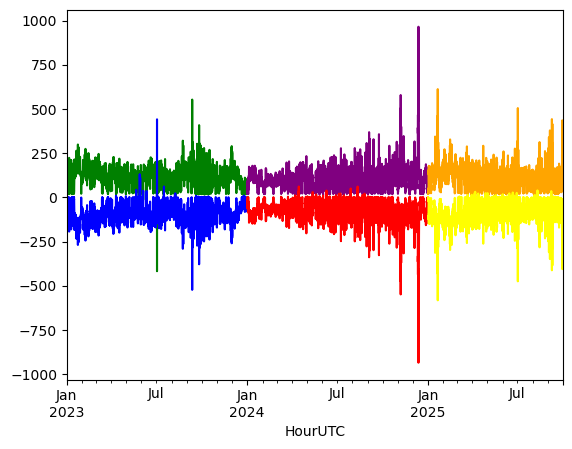

In [49]:
import_price["2023"].plot(color = "green")
import_price["2024"].plot(color = "purple")
import_price["2025"].plot(color = "orange")
export_price["2023"].plot(color = "blue")
export_price["2024"].plot(color = "red")
export_price["2025"].plot(color = "yellow")



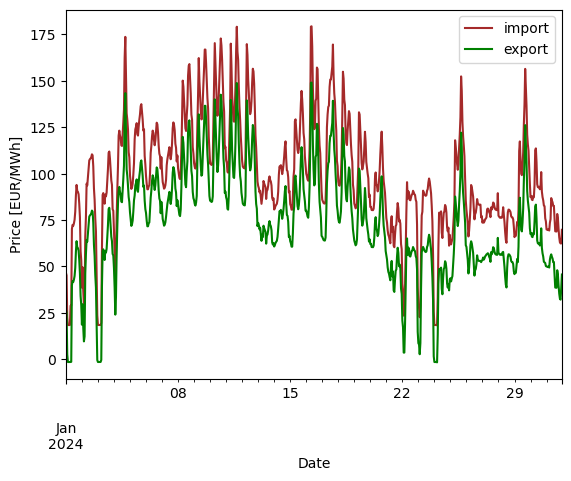

In [83]:
import_price["2024-01-01":"2024-01-31"].plot(color = "brown", label = "import")
(-export_price["2024-01-01":"2024-01-31"]).plot(color = "green", label = "export") 
plt.xlabel("Date")
plt.ylabel("Price [EUR/MWh]")
plt.legend()

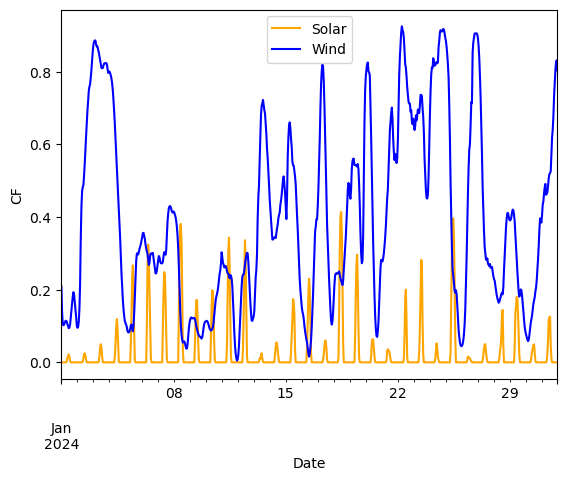

In [86]:
CF_solar["2024-01-01":"2024-01-31"].plot(color = "orange", label = "Solar")
CF_wind["2024-01-01":"2024-01-31"].plot(color = "blue", label = "Wind") 
plt.xlabel("Date")
plt.ylabel("CF")
plt.legend()

### Natural Gas Prices

In [91]:
current_dir = os.getcwd()

In [92]:
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

In [96]:
gas_price_data = pd.read_excel(gas_file)

In [98]:
# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [101]:
EUR_DKK_exchangerate =(gas_price_hourly["ExchangeRateEUR_DKK"]/100)

<Axes: xlabel='GasDay'>

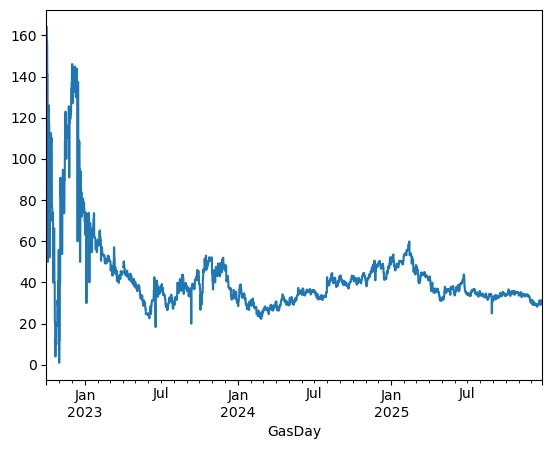

In [102]:
((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000).plot() # EUR/MWh

In [104]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchnagerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] 

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

#### Initialisation of Model and Components

In [105]:
def get_time_period(start='2017-01-01', end='2017-12-31', freq='h', tz_naive=True):
    """
    Generates a pandas DatetimeIndex for a specified period.

    Args:
        start (str): Start date/time (e.g., '2017-01-01' or '2017-01-01 00:00Z')
        end (str): End date/time
        freq (str): Frequency (default 'h' for hourly)
        tz_naive (bool): If True, removes timezone info (localized to None)
        
    Returns:
        pd.DatetimeIndex
    """
    # Create the range
    dr = pd.date_range(start=start, end=end, freq=freq)
    
    # Strip timezone if requested
    if tz_naive and dr.tz is not None:
        dr = dr.tz_localize(None)
    elif tz_naive and dr.tz is None:
        # Even if not localized, ensure it's naive if strings had offsets
        dr = dr.tz_localize(None)
        
    return dr

In [106]:
time_period = get_time_period('2023-01-01 00:00Z', '2023-12-31 23:00Z', freq = "h")
time_period

DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[ns]', length=8760, freq=None)

In [ ]:
### Key Data

"2023";
CF_s23 = CF_solar["2023"]
CF_w23 = CF_wind["2023"]
NG_price_23 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2023"]
#----------------------------------
"2024";
CF_s24 = CF_solar["2024"]
CF_w24 = CF_wind["2024"]
NG_price_24 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2024"]
#-----------------------------------


In [143]:
len(CF_s23), len(CF_w23), len(NG_price_23)
len(CF_s24), len(CF_w24), len(NG_price_24)

(8784, 8784, 8784)

In [123]:
def add_carriers(n):
    #n.add("Carrier",'electricity grid im')
    #n.add("Carrier","electricity grid ex") 
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    #n.add("Carrier","electric boiler")
    #n.add("Carrier","Rondo charge")
    #n.add("Carrier","Rondo store")
    #n.add("Carrier","Rondo discharge")
    n.add("Carrier","heat")
    #n.add("Carrier","battery storage")
    n.add("Carrier","electricity")
    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    n.add("Carrier", "pellets") 
    n.add("Carrier", "CO2") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis")
    n.add("Carrier", "hydrogen")

In [144]:
def add_skive_generators(n):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "EuroWind" ,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= CF_s23, 
        p_nom = 36)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "EuroWind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= CF_w23.values,
        p_nom = 54)

    #--------------------------------
    # PPA link
    n.add("Link", "PPA",
          bus0="EuroWind",
          bus1="Greenlab",
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity")

In [125]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          efficiency=1.0,
          marginal_cost=5e-6,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="EuroWind",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="EuroWind",
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)


In [126]:
def add_battery(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="EuroWind",  # Use your electricity bus name
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [127]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom_store, # MWh
        e_nom_extendable=False,
        e_initial=0,
        e_cyclic=True,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=False,
        p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        p_nom = p_nom_discharge,
        p_nom_extendable=False,
        efficiency=0.90,
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [128]:
# 2 Heat Exchanger hence effincecy = 0.9*0.9 = 0.81
def add_heat_exchanger(n):
    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_MT", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)

In [129]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        p_nom = 10, # MW
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"])

In [130]:
# DH_Price = 40 - 60 EUR/MWh
def add_heat_load(n,p_load,DH_cost):

    n.add("Link","MT_Heat_Supply",
        bus0="Heat_MT",
        bus1="Heat_Sink",
        p_nom_extendable=True,
        carrier = "heat",
        marginal_cost = -DH_cost,) # MWh

    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_Sink",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = p_load) # MWh

In [131]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        marginal_cost = NG_price + CO2tax, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,
        capital_cost=5772) 
    

In [132]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t
    
    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="Greenlab",
        bus3="biochar",
        efficiency= 3.7859/7.6748, #"biochar pyrolysis", "heat output" (MWh_th/t_CO2)/ "biochar pyrolysis", "biomass input (MWh_biomass/t_CO2), #bus1 devided by bus0.
        efficiency2= -0.3184/7.6748,   #-"biochar pyrolysis", "electricity input"] (MWh_e/t_CO2) / "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2),
        efficiency3=  1/7.6748,  #1 / "biochar pyrolysis", "biomass input,
        marginal_cost= 2.5909/7.6748, #"biomass HOP", "VOM" (EUR/MWh)/ "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2)? #     
        p_nom_extendable=False,
        p_nom=2,
        carrier="pyrolysis",
        capital_cost=233477) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom_extendable = True,
        marginal_cost=-0.164*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="CO2") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="CO2")

In [133]:
"Adding Electrolyser"
def add_electrolyser(n, P_elec):
    n.add("Link",
    "Electrolyser",
    bus0 = "Greenlab",
    bus1 = "H2_Bus",
    p_nom = P_elec,
    capital_cost = costs.at["Alkaline electrolyzer medium size", "capital_cost"],
    marginal_cost = costs.at["Alkaline electrolyzer medium size", "marginal_cost"],
    efficiency = 0.6,)

    n.add("Store",
    "H2_Storage",
    bus = "H2_Bus",
    e_nom_extendable = True,
    e_cylic = True)

In [134]:
#Fixed demand
def add_el_load(n,p_el):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load",  "Skive_el_Load", 
        bus="Greenlab", 
        p_set= p_el,
        carrier = "electricity") #MWh

In [153]:
def build_network(P_el,P_heat,CO2_tax1, CO2_tax2,p_import,p_export,NG_price,horizon):
     
    n = pypsa.Network()
    #hours = get_time_period('2023-01-01 00:00Z', '2023-12-31 23:00Z', freq = "h")
    #n.set_snapshots(hours)½
    n.set_snapshots(p_import.index)

    add_carriers(n)

    n.add("Bus", "Greenlab", carrier = "electricity")
    n.add("Bus", "EuroWind", carrier = "electricity")
    n.add("Bus", "Grid_Import", carrier = "electricity")
    n.add("Bus", "Grid_Export", carrier = "electricity")
    
    n.add("Bus", "H2_Bus", carrier = "hydrogen")

    n.add("Bus", "Heat_Exchanger_Bus", carrier = "heat")
    n.add("Bus","TES_Rondo", carrier = "heat")
    n.add("Bus", "Heat_MT", carrier = "heat")
    n.add("Bus","Heat_Sink", carrier = "heat")

    n.add("Bus", "NG", carrier = "gas")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "biochar", carrier="CO2")
    n.add("Bus", "biochar sequestration", carrier="CO2")


    add_battery(n,P_nom = 22, max_t = 2, cyclic_operation = True)
    add_skive_generators(n) # 90 EUR/MWh
    add_grid(n,p_import,p_export)

    add_el_load(n,P_el)
    add_heat_load(n,P_heat,DH_cost = 0) # 50 EUR/MWh

    add_electrolyser(n, P_elec = 12)

    add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n,CO2_tax1,NG_price)
    add_SkyClean(n,CO2_tax2)

    #print(n.consistency_check())
    # 3. Optimize and return the actual network object 'n'
    # SOLVING
    if horizon is not None:
        # Solving in chunks (useful for large datasets or limited memory)
        n.optimize.optimize_with_rolling_horizon(solver_name="gurobi", horizon=horizon)
    else:
        # Solving the full year at once
        n.optimize(solver_name="gurobi")

    return n

In [147]:
CF_s23, CF_w23, NG_price_23 

import_price["2023"], export_price["2023"]

(HourUTC
 2023-01-01 00:00:00    19.912405
 2023-01-01 01:00:00    18.622405
 2023-01-01 02:00:00    18.612405
 2023-01-01 03:00:00    18.582405
 2023-01-01 04:00:00    18.532405
                          ...    
 2023-12-31 19:00:00    57.560058
 2023-12-31 20:00:00    52.270059
 2023-12-31 21:00:00    51.340059
 2023-12-31 22:00:00    49.540060
 2023-12-31 23:00:00    39.660059
 Length: 8760, dtype: float64,
 HourUTC
 2023-01-01 00:00:00    -0.000782
 2023-01-01 01:00:00     1.289218
 2023-01-01 02:00:00     1.299218
 2023-01-01 03:00:00     1.329218
 2023-01-01 04:00:00     1.379218
                          ...    
 2023-12-31 19:00:00   -33.510781
 2023-12-31 20:00:00   -28.220782
 2023-12-31 21:00:00   -27.290782
 2023-12-31 22:00:00   -25.490783
 2023-12-31 23:00:00   -15.610782
 Name: SpotPriceEUR, Length: 8760, dtype: float64)

In [154]:
n23 = build_network(P_el = 2,P_heat = 5,CO2_tax1 = 80, CO2_tax2 = 80,p_import = import_price["2023"],p_export = export_price["2023"],NG_price = NG_price_23,horizon = None)

Index(['Skive_Battery'], dtype='object', name='StorageUnit')
Index(['Boiler_Skive'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 11.94it/s]
INFO:linopy.io: Writing time: 5.53s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 32752 iterations and 5.57 seconds (1.09 work units)


INFO:gurobipy:Solved in 32752 iterations and 5.57 seconds (1.09 work units)


Optimal objective -7.287034997e+06


INFO:gurobipy:Optimal objective -7.287034997e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245289 primals, 578169 duals
Objective: -7.29e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [155]:
n23.statistics()

Optimal Capacity  Installed Capacity  \
Generator   electricity              68.97179                 0.0   
            gas                       6.00000                 6.0   
            onshorewind              54.00000                54.0   
            pellets                   2.00000                 0.0   
            solar                    36.00000                36.0   
Link        CO2                       0.26059                 0.0   
            electric boiler          10.00000                10.0   
            electricity             248.90263               204.0   
            gas                       6.00000                 6.0   
            heat                     18.25000                 7.0   
            pyrolysis                 2.00000                 2.0   
Load        electricity               0.00000                 0.0   
            heat                      0.00000                 0.0   
StorageUnit battery storage          22.00000                22.0   
Store       CO2                     131.21362                 0.0   
            electricity           96039.79930                 0.0   
            heat                    100.00000               100.0   
            hydrogen                201.60000                 0.0   

                                   Supply    Withdrawal  Energy Balance  \
Generator   electricity        9330.16625       0.00000      9330.16625   
            gas               11653.10014       0.00000     11653.10014   
            onshorewind      115290.25659       0.00000    115290.25659   
            pellets            1007.03827       0.00000      1007.03827   
            solar             38303.18434       0.00000     38303.18434   
Link        CO2                   0.00000     131.21362      -131.21362   
            electric boiler       0.00000   24485.51485    -24485.51485   
            electricity           0.00000  185126.41554   -185126.41554   
            gas                   0.00000   11653.10014    -11653.10014   
            heat                  0.00000   69783.12505    -69783.12505   
            pyrolysis             0.00000    1007.03827     -1007.03827   
Load        electricity           0.00000   17520.00000    -17520.00000   
            heat                  0.00000   43800.00000    -43800.00000   
StorageUnit battery storage   20792.08463   24104.14121     -3312.05658   
Store       CO2                   0.00000     131.21362      -131.21362   
            electricity           0.00000   96039.79930    -96039.79930   
            heat              13633.66231   15764.36494     -2130.70263   
            hydrogen              0.00000     201.60000      -201.60000   

                             Transmission  Capacity Factor   Curtailment  \
Generator   electricity           0.00000         0.015442  594862.69874   
            gas                   0.00000         0.221710   40906.89986   
            onshorewind           0.00000         0.243722    8457.37493   
            pellets               0.00000         0.057480   16512.96173   
            solar                 0.00000         0.121459     720.45566   
Link        CO2                 131.21362         0.057485       0.00000   
            electric boiler       0.00000         0.279515       0.00000   
            electricity      168661.81187         0.084905       0.00000   
            gas                   0.00000         0.221710       0.00000   
            heat              69783.12505         0.436499       0.00000   
            pyrolysis             0.00000         0.057480       0.00000   
Load        electricity           0.00000              NaN       0.00000   
            heat                  0.00000              NaN       0.00000   
StorageUnit battery storage       0.00000         0.232961  196032.05658   
Store       CO2                   0.00000         0.915231       0.00000   
            electricity           0.00000         0.529689       0.00000   

<Axes: xlabel='snapshot'>

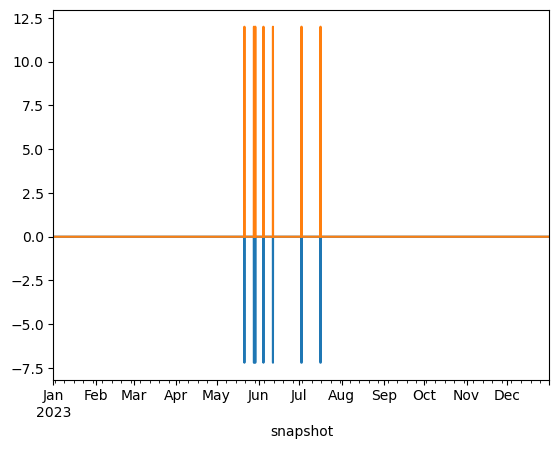

In [156]:
#model_test.links_t.p1["El_to_TES_Rondo"].plot()
n23.links_t.p1["Electrolyser"].plot()
n23.links_t.p0["Electrolyser"].plot()

In [181]:

(n23.links_t.p1["Heat_Exchanger_Rondo"] + n23.links_t.p1["Boiler_Skive"] + n23.links_t.p1["NG boiler"] + n23.links_t.p1["pyrolysis"])

snapshot
2023-01-01 00:00:00   -5.0
2023-01-01 01:00:00   -5.0
2023-01-01 02:00:00   -5.0
2023-01-01 03:00:00   -5.0
2023-01-01 04:00:00   -5.0
                      ... 
2023-12-31 19:00:00   -5.0
2023-12-31 20:00:00   -5.0
2023-12-31 21:00:00   -5.0
2023-12-31 22:00:00   -5.0
2023-12-31 23:00:00   -5.0
Length: 8760, dtype: float64

<Axes: xlabel='snapshot'>

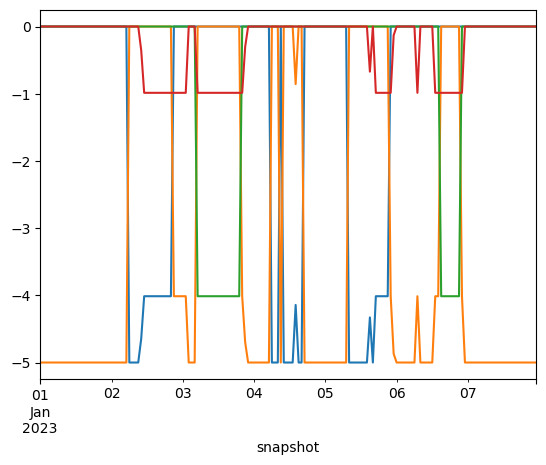

In [ ]:
n23.links_t.p1["Heat_Exchanger_Rondo"][0:24*7].plot()
n23.links_t.p1["Boiler_Skive"][0:24*7].plot()
n23.links_t.p1["NG boiler"][0:24*7].plot()
n23.links_t.p1["pyrolysis"][0:24*7].plot()


(0.0, 100.0)

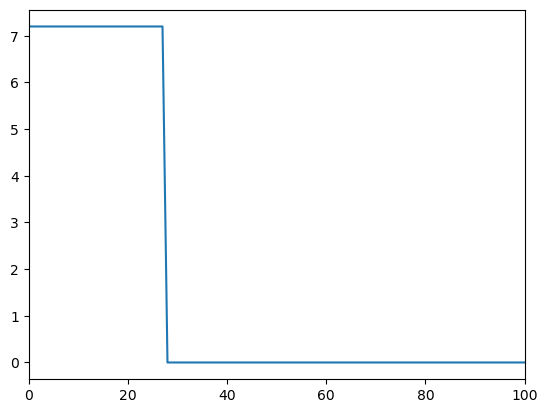

In [209]:
duration_electrolysis23 = -n23.links_t.p1["Electrolyser"].sort_values(ascending=True)
plt.plot(duration_electrolysis23.values)
plt.xlim(0,100)

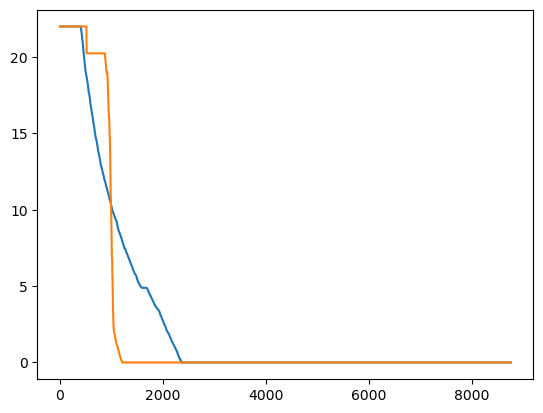

In [207]:
plt.plot(np.sort(n23.storage_units_t.p_store["Skive_Battery"])[::-1])
plt.plot(np.sort(n23.storage_units_t.p_dispatch["Skive_Battery"])[::-1])
